In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

In [4]:
# 1. Load the Dataset
df = pd.read_csv('Mall_Customers.csv')

In [5]:
# 2. Statistical Analysis & EDA
print("--- Data Info ---")
print(df.info())
print("\n--- Descriptive Statistics ---")
print(df.describe())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

--- Descriptive Statistics ---
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000        

In [6]:
# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


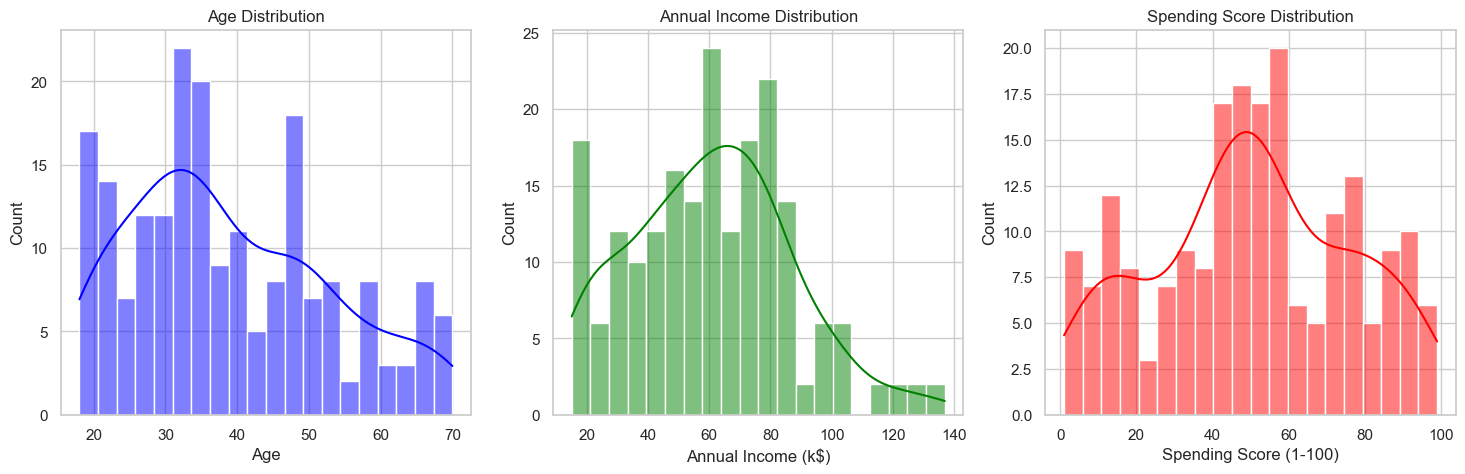

In [7]:
# Visualizing distributions
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='blue').set_title('Age Distribution')
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, ax=axes[1], color='green').set_title('Annual Income Distribution')
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, ax=axes[2], color='red').set_title('Spending Score Distribution')
plt.show()

In [8]:
# 3. Feature Selection & Engineering
# We select Age, Annual Income, and Spending Score for clustering
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [9]:
# Feature Scaling (Crucial for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


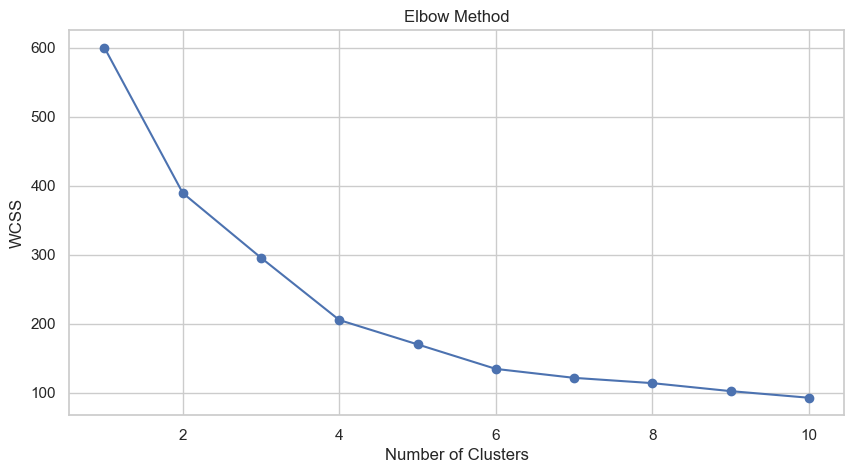

In [10]:
# 4. Finding Optimal K (Evaluation)
# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [11]:
# Silhouette Score
for n_clusters in range(2, 7):
    clusterer = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = clusterer.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is: {silhouette_avg:.4f}")

For n_clusters = 2, the average silhouette_score is: 0.3355
For n_clusters = 3, the average silhouette_score is: 0.3579
For n_clusters = 4, the average silhouette_score is: 0.4040
For n_clusters = 5, the average silhouette_score is: 0.4085
For n_clusters = 6, the average silhouette_score is: 0.4311


In [12]:
# 5. Model Building (Applying K-Means)
# Based on the Elbow and Silhouette scores, K=6 is a strong candidate
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [13]:
# 6. Cluster Analysis
cluster_summary = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Count'})

print("\n--- Cluster Profile Summary ---")
print(cluster_summary)


--- Cluster Profile Summary ---
               Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                              
0        56.333333           54.266667               49.066667     45
1        32.692308           86.538462               82.128205     39
2        25.560000           26.480000               76.240000     25
3        26.125000           59.425000               44.450000     40
4        44.000000           90.133333               17.933333     30
5        45.523810           26.285714               19.380952     21


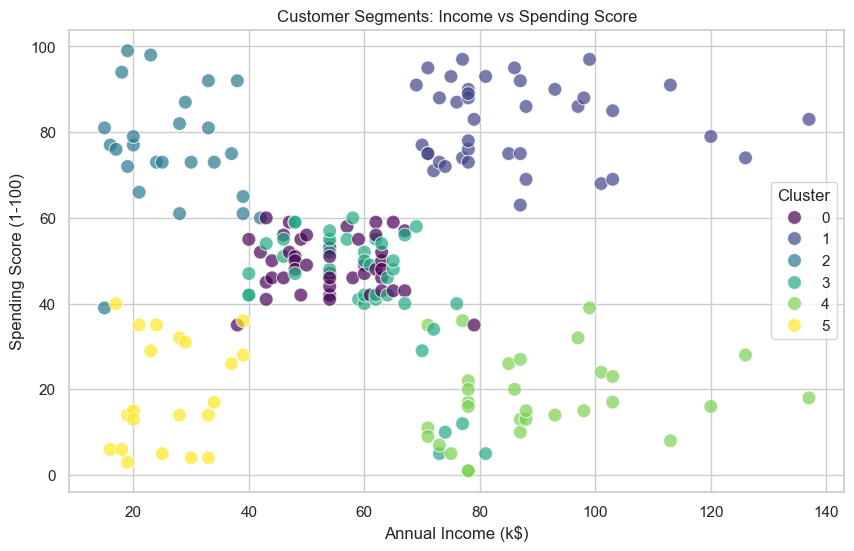

In [14]:
# 7. Visualization of Clusters
# 2D Projection (Income vs Spending)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Customer Segments: Income vs Spending Score')
plt.show()

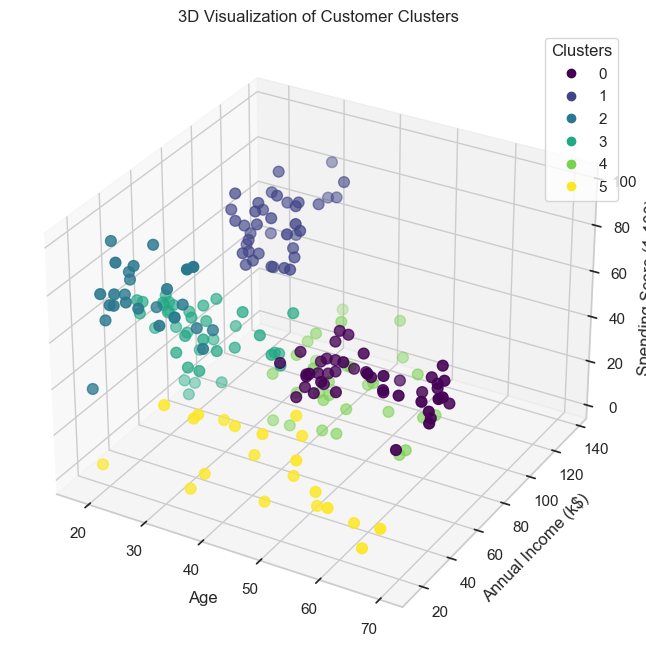

In [15]:
# 3D Visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'], 
                     c=df['Cluster'], s=60, cmap='viridis')

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
plt.title('3D Visualization of Customer Clusters')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [16]:
# Save results
df.to_csv('Mall_Customers_Clustered_output_file.csv', index=False)

In [17]:
# 8. Prediction for New Customers
def predict_cluster(age, income, spending_score):
    """
    Predicts the cluster for a new customer.
    Input: Age, Annual Income, Spending Score
    """
    # Scale the input using the pre-fitted scaler
    new_data = np.array([[age, income, spending_score]])
    new_data_scaled = scaler.transform(new_data)
    
    # Predict the cluster
    cluster = kmeans.predict(new_data_scaled)
    return cluster[0]

# Example Prediction
sample_customer = [25, 20, 80] # Young, Low Income, High Spending
pred = predict_cluster(*sample_customer)
print(f"\nNew Customer {sample_customer} belongs to Cluster: {pred}")



New Customer [25, 20, 80] belongs to Cluster: 2
